# Facebook Ads Performance Analysis

## Objective

The goal of this project is to analyze Facebook advertising campaign performance using data analysis and visualization techniques. The analysis focuses on understanding spending patterns, campaign profitability (ROMI), and relationships between key performance metrics.

## Data Description

The dataset contains daily Facebook ads performance data, including:

- ad_date: Date of the campaign activity  
- campaign_name: Name of the campaign  
- total_spend: Total advertising cost  
- total_impressions: Number of times ads were shown  
- total_clicks: Number of clicks  
- total_value: Revenue generated  
- cpc: Cost per click  
- cpm: Cost per 1000 impressions  
- ctr: Click-through rate  
- romi: Return on marketing investment  

## Analysis Steps

1. Data loading and preprocessing  
2. Filtering data for 2021  
3. Daily aggregation and ROMI calculation  
4. Time series analysis (spend & ROMI)  
5. Rolling average analysis  
6. Campaign-level analysis  
7. Distribution analysis (boxplot & histogram)  
8. Correlation analysis  
9. Regression analysis  

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
df = pd.read_csv('facebook_ads_data.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ad_date            1494 non-null   object 
 1   campaign_name      1494 non-null   object 
 2   total_spend        1494 non-null   float64
 3   total_impressions  1494 non-null   int64  
 4   total_clicks       1494 non-null   int64  
 5   total_value        1494 non-null   float64
 6   cpc                1443 non-null   float64
 7   cpm                1462 non-null   float64
 8   ctr                1462 non-null   float64
 9   romi               1462 non-null   float64
dtypes: float64(6), int64(2), object(2)
memory usage: 116.8+ KB


In [6]:
df.head()

,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
0,2022-11-05,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
1,2022-11-01,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
2,2022-10-31,Expansion,227.45,6054,58,191.87,3.92,37.57,0.009580,0.843570
3,2022-10-30,Expansion,335.91,27562,69,472.61,4.87,12.19,0.002503,1.406954
4,2022-10-29,Expansion,714.03,33358,115,680.34,6.21,21.41,0.003447,0.952817


In [7]:
# Convert date column
df['ad_date'] = pd.to_datetime(df['ad_date'])

# Filter 2021
df_2021 = df[df['ad_date'].dt.year == 2021]

# Group by date
daily_data = df_2021.groupby('ad_date', as_index=False).agg({
    'total_spend': 'sum',
    'total_value': 'sum'
})

# Calculate ROMI
daily_data['ROMI'] = (daily_data['total_value'] - daily_data['total_spend']) / daily_data['total_spend']

# Fix infinite values (important!)
daily_data['ROMI'] = daily_data['ROMI'].replace([float('inf'), -float('inf')], 0)

daily_data.head()

,ad_date,total_spend,total_value,ROMI
0,2021-01-01,0.39,0.59,0.512821
1,2021-01-02,7.74,6.90,-0.108527
2,2021-01-04,70.06,68.47,-0.022695
3,2021-01-05,81.15,61.68,-0.239926
4,2021-01-06,142.77,145.97,0.022414


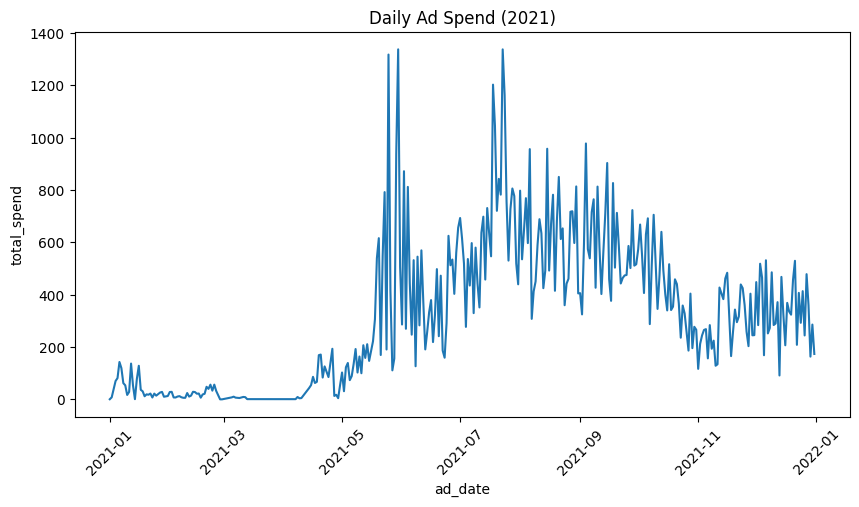

In [8]:
plt.figure(figsize=(10,5))
sns.lineplot(data=daily_data, x='ad_date', y='total_spend')
plt.title('Daily Ad Spend (2021)')
plt.xticks(rotation=45)
plt.show()

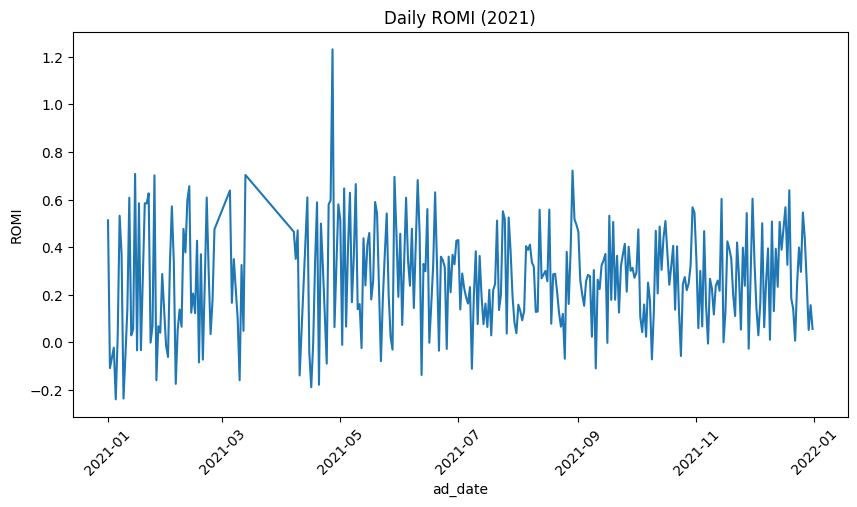

In [9]:
plt.figure(figsize=(10,5))
sns.lineplot(data=daily_data, x='ad_date', y='ROMI')
plt.title('Daily ROMI (2021)')
plt.xticks(rotation=45)
plt.show()

In [10]:
daily_data['spend_rolling'] = daily_data['total_spend'].rolling(7).mean()
daily_data['ROMI_rolling'] = daily_data['ROMI'].rolling(7).mean()

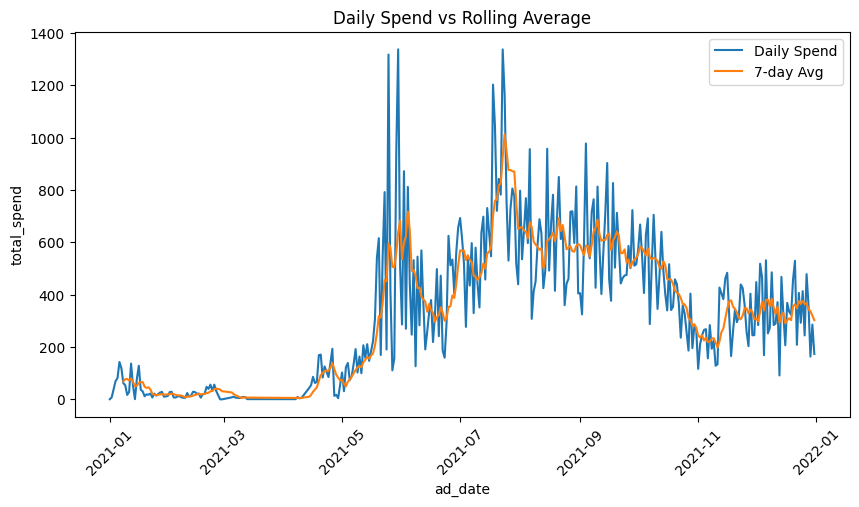

In [11]:
plt.figure(figsize=(10,5))

sns.lineplot(data=daily_data, x='ad_date', y='total_spend', label='Daily Spend')
sns.lineplot(data=daily_data, x='ad_date', y='spend_rolling', label='7-day Avg')

plt.title('Daily Spend vs Rolling Average')
plt.xticks(rotation=45)
plt.legend()
plt.show()

### Interpretation

Daily ad spend shows strong fluctuations throughout 2021, with noticeable peaks in mid-year. The 7-day rolling average smooths short-term volatility and makes the overall trend easier to understand. ROMI values vary significantly, which suggests that campaign profitability was not stable across all days.

In [12]:
campaign_data = df.groupby('campaign_name', as_index=False).agg({
    'total_spend': 'sum',
    'total_value': 'sum'
})

campaign_data['ROMI'] = (campaign_data['total_value'] - campaign_data['total_spend']) / campaign_data['total_spend']
campaign_data['ROMI'] = campaign_data['ROMI'].replace([float('inf'), -float('inf')], 0)

campaign_data.head()

,campaign_name,total_spend,total_value,ROMI
0,Brand,539.92,670.15,0.241202
1,Crazy discounts,2175.29,2583.59,0.187699
2,Discounts,2856.39,3516.27,0.231019
3,Electronics,23920.42,29169.38,0.219434
4,Expansion,67212.82,83288.66,0.239178


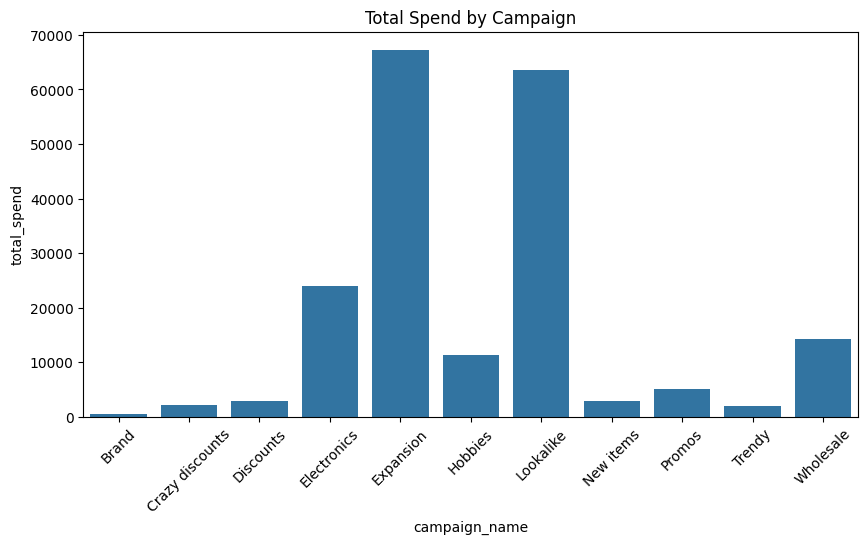

In [13]:
plt.figure(figsize=(10,5))

sns.barplot(data=campaign_data, x='campaign_name', y='total_spend')

plt.title('Total Spend by Campaign')
plt.xticks(rotation=45)

plt.show()

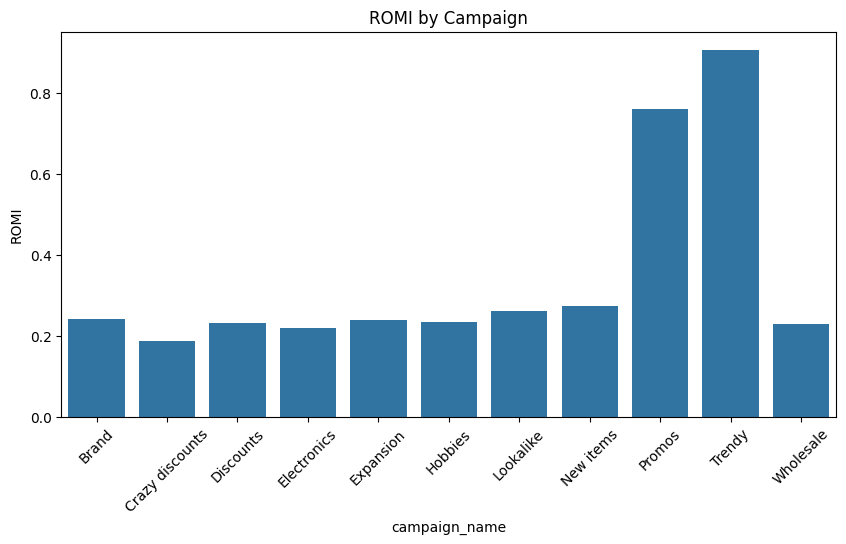

In [14]:
plt.figure(figsize=(10,5))

sns.barplot(data=campaign_data, x='campaign_name', y='ROMI')

plt.title('ROMI by Campaign')
plt.xticks(rotation=45)

plt.show()

### Campaign Analysis Interpretation

Campaign performance varies across different campaigns. While some campaigns generate higher total spend, their profitability (ROMI) does not always increase proportionally. This suggests that higher investment does not always guarantee better returns, and campaign efficiency should be evaluated alongside total spend.

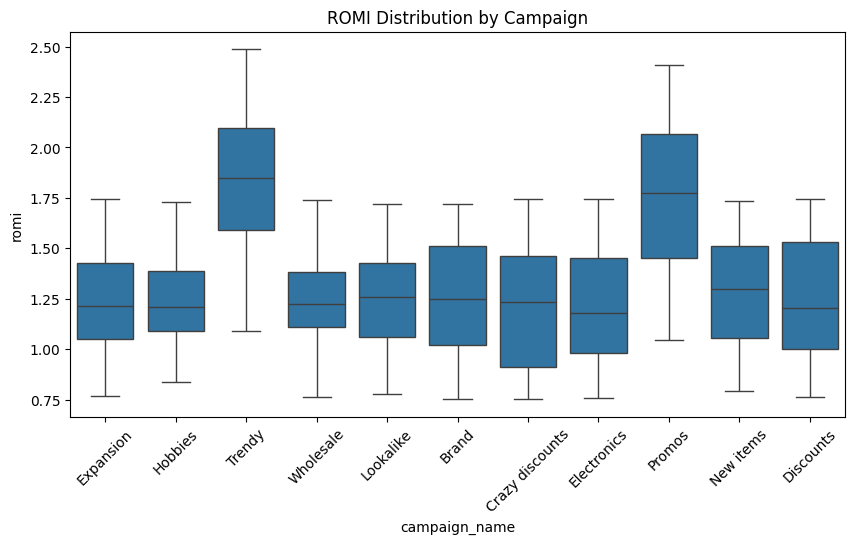

In [15]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x='campaign_name', y='romi')

plt.title('ROMI Distribution by Campaign')
plt.xticks(rotation=45)

plt.show()

### ROMI Distribution Interpretation

The boxplot reveals that ROMI distribution differs significantly across campaigns. While some campaigns maintain relatively stable returns, others exhibit wider variability and potential outliers. This suggests that certain campaigns carry higher performance risk and should be evaluated not only by their average ROMI but also by their consistency.

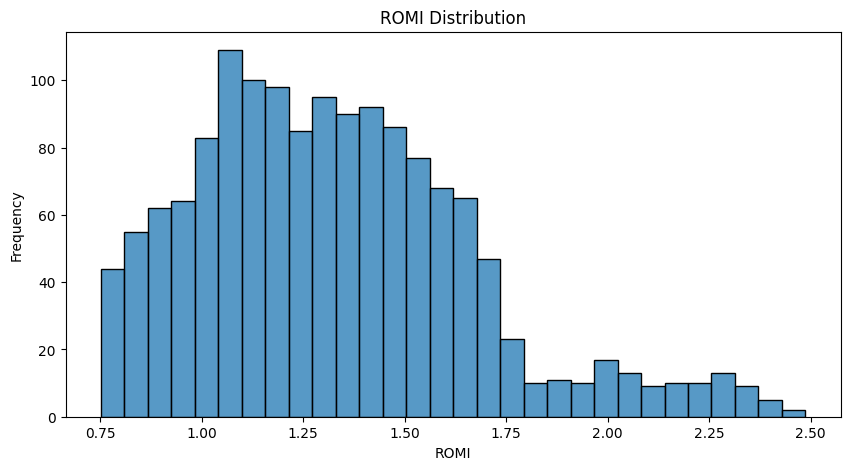

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(df['romi'], bins=30)

plt.title('ROMI Distribution')
plt.xlabel('ROMI')
plt.ylabel('Frequency')

plt.show()

### ROMI Histogram Interpretation

The histogram shows that most ROMI values are concentrated between approximately 1.0 and 1.6, indicating a generally moderate profitability level across campaigns. A smaller number of higher values suggests the presence of high-performing campaigns, while the right tail indicates potential positive outliers.

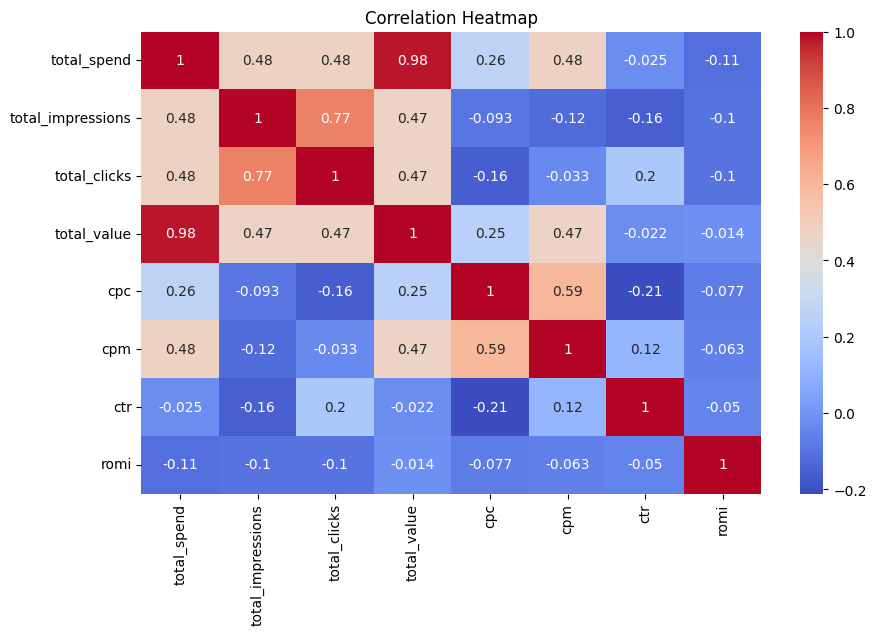

In [17]:
# Select numeric columns only
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Correlation matrix
correlation = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

### Correlation Analysis Interpretation

The heatmap reveals strong relationships between several key variables. The highest correlation is observed between total_spend and total_value (0.98), indicating that revenue is highly dependent on advertising investment.

Total_value also shows moderate positive correlations with total_clicks and total_impressions, suggesting that both user engagement and reach contribute to revenue generation.

Some variables, such as CTR and CPC, show weak or negative correlations with other metrics, indicating limited or inverse relationships.

Overall, the analysis suggests that while higher spend drives higher revenue, efficiency metrics like ROMI are less directly correlated and should be evaluated separately.

Interestingly, ROMI does not show strong correlation with other variables, indicating that higher investment does not necessarily guarantee higher profitability.

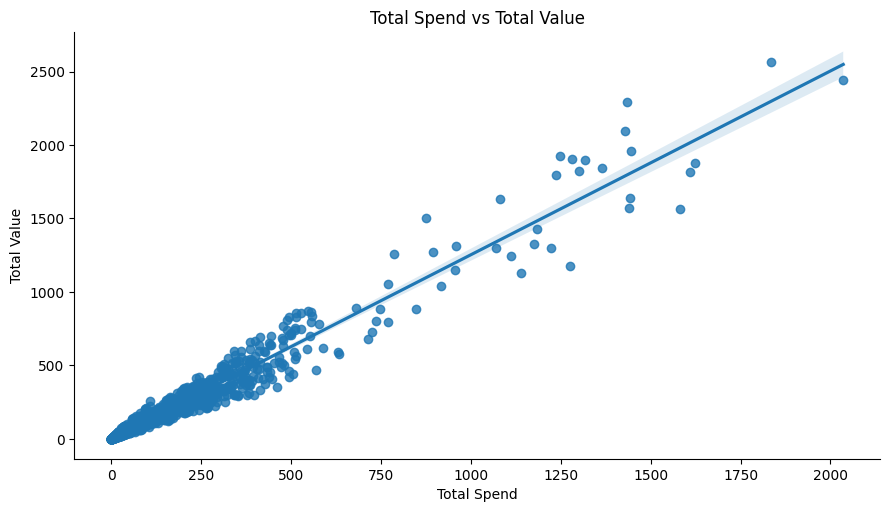

In [18]:
sns.lmplot(data=df, x='total_spend', y='total_value', height=5, aspect=1.8)

plt.title('Total Spend vs Total Value')
plt.xlabel('Total Spend')
plt.ylabel('Total Value')

plt.show()

### Regression Analysis Interpretation

The regression plot demonstrates a very strong linear relationship between total spend and total value. The data points closely follow the regression line, indicating a consistent and predictable increase in revenue as advertising investment grows.

This suggests that increasing ad spend reliably drives higher revenue, although, as observed earlier, it does not necessarily guarantee higher profitability (ROMI).

## Conclusion

The analysis shows that advertising spend strongly influences revenue generation. However, profitability (ROMI) is not directly correlated with spending, indicating that higher investment does not always lead to better efficiency.

Campaign performance varies significantly, highlighting the importance of evaluating both revenue and profitability metrics when making marketing decisions.